# Model validation

In [1]:
from model import STGAETransformerPoolingMultiGCN
import torch 
import xarray as xr
import matplotlib.pyplot as plt

## Load the model

In [2]:
hidden_channels = 64
latent_dim = 16
num_epochs = 8
initial_lr = 0.001    
lr_decay_epochs = num_epochs-2 
lr_gamma = 0.5       
checkpoint_dir = "./anomaly_detector"
accumulation_steps = 2
temp_window = 25
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = STGAETransformerPoolingMultiGCN(temp_window*2, hidden_channels, latent_dim).to(device)
model.load_state_dict(torch.load('anomaly_detector/stgae_epoch_8.pth', weights_only=True))

<All keys matched successfully>

## Load the dataset

In [3]:
import os 
lat_min, lat_max = 30, 60
lon_min, lon_max = 0, 30
time_window = 20

dataset_base_directory = os.curdir+os.sep+"dataset"
dataset_files = dataset_base_directory+os.sep+'*.nc4'

ds = xr.open_mfdataset(dataset_files, cache=False)
ds

<xarray.Dataset> Size: 745GB
Dimensions:  (time: 5706, lat: 3298, lon: 9896)
Coordinates:
  * lon      (lon) float32 40kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
  * lat      (lat) float32 13kB -59.98 -59.95 -59.91 ... 59.91 59.95 59.98
  * time     (time) datetime64[ns] 46kB 2020-01-01 ... 2020-04-28T20:30:00.00...
Data variables:
    Tb       (time, lat, lon) float32 745GB dask.array<chunksize=(1, 1649, 2474), meta=np.ndarray>
Attributes:
    BeginDate:       2020-01-01
    BeginTime:       00:00:00.000Z
    EndDate:         2020-01-01
    EndTime:         00:59:59.999Z
    FileHeader:      StartGranuleDateTime=2020-01-01T00:00:00.000Z;\nStopGran...
    InputPointer:    merg_2020010100_4km-pixel
    title:           NCEP/CPC 4km Global (60N - 60S) IR Dataset
    ProductionTime:  2020-01-03T00:19:23.203Z

In [4]:
ds = ds.sel(
    lat=slice(lat_min, lat_max), 
    lon=slice(lon_min, lon_max) 
)
ds = ds.chunk({'time': time_window})
ds['Tb'] = ds['Tb'].astype('float16')

Select a subset of the dataset for the network performance testing

In [5]:
import random
t1 = random.randint(0, ds['time'].shape[0]-temp_window)
ds_time_slice = ds.isel(time=slice(t1, t1+temp_window))
ds_time_slice

<xarray.Dataset> Size: 34MB
Dimensions:  (time: 25, lat: 825, lon: 825)
Coordinates:
  * lon      (lon) float32 3kB 0.01819 0.05457 0.09094 ... 29.92 29.96 29.99
  * lat      (lat) float32 3kB 30.0 30.04 30.07 30.11 ... 59.91 59.95 59.98
  * time     (time) datetime64[ns] 200B 2020-02-23T12:30:00.000013312 ... 202...
Data variables:
    Tb       (time, lat, lon) float16 34MB dask.array<chunksize=(11, 825, 825), meta=np.ndarray>
Attributes:
    BeginDate:       2020-01-01
    BeginTime:       00:00:00.000Z
    EndDate:         2020-01-01
    EndTime:         00:59:59.999Z
    FileHeader:      StartGranuleDateTime=2020-01-01T00:00:00.000Z;\nStopGran...
    InputPointer:    merg_2020010100_4km-pixel
    title:           NCEP/CPC 4km Global (60N - 60S) IR Dataset
    ProductionTime:  2020-01-03T00:19:23.203Z

## Prepare poisoned data

In [6]:
from attacks import *
from torch import autocast
import torch.nn.functional as F

In [7]:
def compute_loss(x_recon, target, loss_type="mse", temp_weight=1.0, mask_weight=0.2):
    T = x_recon.size(1) // 2
    recon_temp = x_recon[:, :T]
    target_temp = target[:, :T]
    recon_mask = x_recon[:, T:]
    target_mask = target[:, T:]
    if loss_type == "mse":
        loss_temp = F.mse_loss(recon_temp, target_temp, reduction='mean')
        loss_mask = F.mse_loss(recon_mask, target_mask, reduction='mean')
    elif loss_type == "mae":
        loss_temp = F.l1_loss(recon_temp, target_temp, reduction='mean')
        loss_mask = F.l1_loss(recon_mask, target_mask, reduction='mean')
    elif loss_type == "smooth_l1":
        loss_temp = F.smooth_l1_loss(recon_temp, target_temp, reduction='mean')
        loss_mask = F.smooth_l1_loss(recon_mask, target_mask, reduction='mean')
    else:
        raise ValueError("Unsupported loss type: " + loss_type)

    return temp_weight * loss_temp + mask_weight * loss_mask
loss_type = 'mse'
def evaluate_sample(data, model, device):
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        with autocast('cuda'):
            x_recon, z, perm = model(data)
    error = compute_loss(x_recon, data.x[perm], loss_type=loss_type)
    del data, x_recon
    torch.cuda.empty_cache()
    return error, z

In [8]:

poisoned_samples = {
    'Fixed Bias': [
        {
            'param_name': 'bias',
            'param_value':f'{bias}',
            'attack': fixed_bias(ds_time_slice, bias) 
        } for bias in range(10, 20, 2)
    ],
    'Incrementing Bias': [
        {
            'param_name': 'increment',
            'param_value':f'{bias_rate}',
            'desc':f'bias increment = {bias_rate}',
            'attack':incrementing_bias(ds_time_slice, bias_rate) 
        } for bias_rate in range(2, 12, 2)
    ],
    'Adversarial Perturbation': [
        {
            'param_name':'Magnitude',
            'param_value': f'{epsilon}',
            'attack': adversarial_perturbation(ds_time_slice, epsilon)
        }
        for epsilon in range(4, 20, 2)
    ],
    'Sensor spoofing': [
        {
            'param_name':None,
            'param_value':None,
            'attack': rnd_sensor_spoofing(ds_time_slice, 50, 100, 50, 100)
        }
         for i in range(5)
    ],
    'Data block jamming': [
        {
            'param_name':'probability',
            'param_value': f'{fraction*10}%',
            'attack': data_block_jamming(ds_time_slice, fraction/10, main_var='Tb') 
        }
        for fraction in range(1, 10)
    ],
    'Temporal shifting': [
        {
            'param_name':'temporal shifting',
            'param_value': f'{shift}',
            'attack': temporal_shifting(ds_time_slice,shift, main_var='Tb') 
        }
        for shift in range(0, 10, 2)
    ],
    'Spatial shifting': [
        {
            'param_name':None,
            'param_value':None,
            'attack': rnd_spatial_shifting(ds_time_slice,200)
        }
         for i in range(5)
    ],
    'Miscalibration error': [
        {
            'param_name':'Error Coefficient',
            'param_value':f'{err/10}',
            'attack': miscalibration_error_injection(ds_time_slice, err/10)
        }
        for err in range(15, 55,5)
    ],
    'Replay attack': [
        {
            'param_name':'Replay Period',
            'param_value':f'{period}',
            'desc': f'replay period={period}',
            'attack': replay_attack(ds_time_slice, period) 
        }
        for period in range(1, 3)
    ],
    'Backdoor attack': [
        {
            'param_name':'Trigger strength',
            'param_value':f'{strength}',
            'attack': backdoor_trigger(ds_time_slice, strength) 
        }
         for strength in range(1, 10)
    ]
}

## Attacks simulation


In [9]:
from dataset import TemperatureGraphDataset, chunk_to_graph


In [10]:
errors = []
mean_temp = 272.51712
std_temp = 15.239919
time_slice_norm = (ds_time_slice-mean_temp)/std_temp
dataset = TemperatureGraphDataset(time_slice_norm, 'Tb', temp_window, rnd_offset=False)

error, latent = evaluate_sample(dataset.get(0), model, device)
anomaly_threshold = error.mean().item()
print(f"Average reconstruction error per node:", error.mean().item())

Average reconstruction error per node: 0.31969964504241943


In [11]:
for label, attacks in poisoned_samples.items():
    print(f'''
          #########  {label}  #########
          ''')
    for attack in attacks:   
        attack_norm = (attack['attack']-mean_temp)/std_temp
        attack_norm = attack_norm['Tb'].compute()
        attack_norm = chunk_to_graph(attack_norm, temp_window)
        error, latent = evaluate_sample(attack_norm, model, device)
        err = error.mean().item()
        errors.append(err)
        attack['result'] = err
        description = "("+attack['param_name']+"="+attack['param_value']+")" if not attack['param_name'] is None else ""
        print(f"{label} {description} - average reconstruction error per node:", error.mean().item())


          #########  Fixed Bias  #########
          
Fixed Bias (bias=10) - average reconstruction error per node: 0.18491876125335693
Fixed Bias (bias=12) - average reconstruction error per node: 0.1620464324951172
Fixed Bias (bias=14) - average reconstruction error per node: 0.14846594631671906
Fixed Bias (bias=16) - average reconstruction error per node: 0.1470061093568802
Fixed Bias (bias=18) - average reconstruction error per node: 0.1565479338169098

          #########  Incrementing Bias  #########
          
Incrementing Bias (increment=2) - average reconstruction error per node: 0.31666824221611023
Incrementing Bias (increment=4) - average reconstruction error per node: 1.1502913236618042
Incrementing Bias (increment=6) - average reconstruction error per node: 2.6268150806427
Incrementing Bias (increment=8) - average reconstruction error per node: 4.646509647369385
Incrementing Bias (increment=10) - average reconstruction error per node: 7.228691101074219

          ########

TypeError: object of type 'float' has no len()

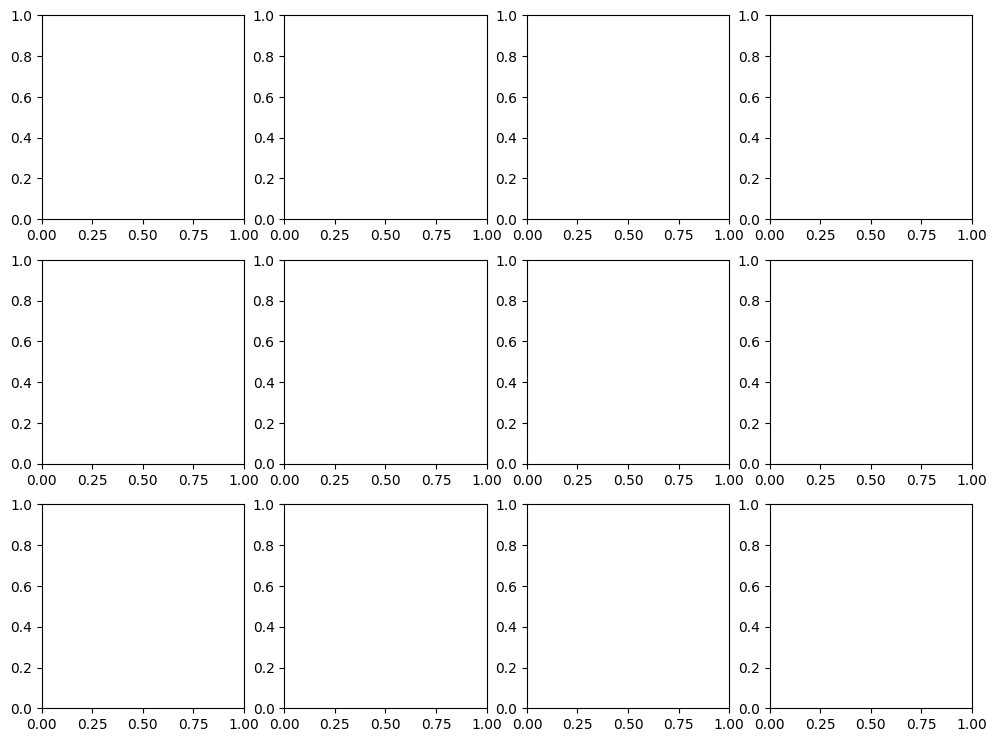

In [ ]:
num_attacks = len(poisoned_samples)
cols = 4
rows = (num_attacks + cols - 1) // cols  # Calculate the number of rows needed

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
axes = axes.flatten()  # Flatten the axes array for easy iteration

for ax, (label, attacks) in zip(axes, poisoned_samples.items()):
    for attack in attacks:
        param_value = attack.get('param_value')
        param_name = attack.get('param_name', '')
        if param_value is not None:
            ax.plot(param_value, attack['result'], marker='o')
            ax.set_xlabel(param_name)
            ax.set_ylabel('Reconstruction Error')
            ax.set_title(f'{label} Reconstruction')
            ax.legend([label])
            ax.axhline(y=anomaly_threshold, color='r', linestyle='--')  
        else:
            ax.plot(1, attack['result'], marker='o')
            ax.set_xlabel(param_name)
            ax.set_ylabel('Reconstruction Error')
            ax.set_title(f'{label} Reconstruction')
            ax.legend([label])
            ax.axhline(y=anomaly_threshold, color='r', linestyle='--') 

# Hide any unused subplots
for i in range(num_attacks, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [17]:
precision = 0
for error in errors:
    precision += 1 if error>anomaly_threshold else 0
print(f"Anomalies were detected with {precision/len(errors)*100}% accuracy")

Anomalies were detected with 77.04918032786885% accuracy
